In [ ]:
%pip install lifelines

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Load and map dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.rename(columns={'customerID': 'user_id', 'MonthlyCharges': 'monthly_spend'})

# 2. Synthesize dates
mock_today = pd.to_datetime('2024-01-01')
tenure_days = df['tenure'] * 30.436875
df['signup_date'] = mock_today - pd.to_timedelta(tenure_days, unit='D')
df['cancel_date'] = np.where(df['Churn'] == 'Yes', mock_today, pd.NaT)
df['last_active_date'] = mock_today
df = df.drop(columns=['tenure'])

# 3. Right-censoring & Tenure Calculation
observation_date = df[['signup_date', 'cancel_date', 'last_active_date']].max().max()
df['churned'] = df['cancel_date'].notnull().astype(int)
df['effective_end_date'] = df['cancel_date'].fillna(observation_date)
df['tenure_months'] = (df['effective_end_date'] - df['signup_date']).dt.days / 30.436875

print(f"Dataset ready. Total records: {len(df)}")

Dataset ready. Total records: 7043


In [9]:
# Instantiate the Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# Fit the model using tenure durations and the binary churn event flag
kmf.fit(
    durations=df['tenure_months'], 
    event_observed=df['churned'], 
    label='Overall SaaS Base'
)

# Confirm right-censored users are retained, not dropped
total_users = len(df)
churned_users = df['churned'].sum()
censored_users = total_users - churned_users

print("--- Survival Model Data Summary ---")
print(f"Total Users Fed to Model: {total_users}")
print(f"Observed Churn Events:    {churned_users}")
print(f"Right-Censored (Active):  {censored_users} ({(censored_users/total_users)*100:.1f}%)")

# Display the calculated survival probability at specific month milestones
print("\n--- Survival Probabilities ---")
print(kmf.predict([0, 12, 24, 36, 48, 60]).round(3))

--- Survival Model Data Summary ---
Total Users Fed to Model: 7043
Observed Churn Events:    1869
Right-Censored (Active):  5174 (73.5%)

--- Survival Probabilities ---
0     1.000
12    0.843
24    0.789
36    0.749
48    0.709
60    0.664
Name: Overall SaaS Base, dtype: float64


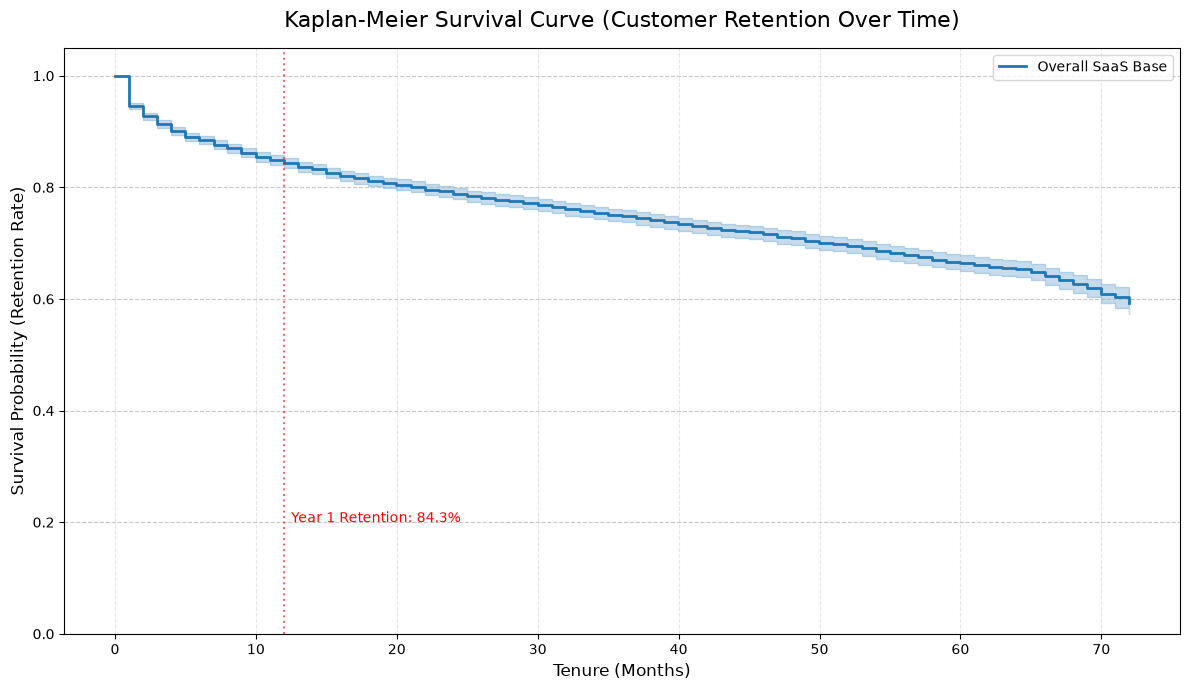

In [10]:
plt.figure(figsize=(12, 7))

# lifelines has a built-in plotting method that includes confidence intervals
ax = kmf.plot_survival_function(color='#1f77b4', linewidth=2)

plt.title('Kaplan-Meier Survival Curve (Customer Retention Over Time)', fontsize=16, pad=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Survival Probability (Retention Rate)', fontsize=12)

# Set y-axis limit to 0-1 (0% to 100% retention)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add a marker line for the 1-year (12 month) mark
one_year_prob = kmf.predict(12)
plt.axvline(x=12, color='red', linestyle=':', alpha=0.6)
plt.text(12.5, 0.2, f'Year 1 Retention: {one_year_prob:.1%}', color='red')

plt.tight_layout()
plt.show()